In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import xarray as xr
import scipy.io as sio
from datetime import datetime, timedelta

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


### SOLO function to compute core ESP paramters

In [2]:
# def solo(l, VT, VN, core_thresh=30_000):
#     l, VT, VN = map(np.asarray, (l, VT, VN))
#     m = np.isfinite(l) & np.isfinite(VT) & np.isfinite(VN)
#     l, VT, VN = l[m], VT[m], VN[m]
#     if l.size < 4:
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     def root_near_mid(x, y):
#         c = np.polyfit(x, y, 3)
#         r = np.roots(c)
#         r = r[np.isreal(r)].real
#         if r.size == 0:
#             return np.nan
#         mid = x[x.size // 2]
#         return r[np.argmin(np.abs(r - mid))]

#     def tangent_fit(x, y, x0):
#         c = np.polyfit(x, y, 3)
#         slope = np.polyval(np.polyder(c), x0)
#         intercept = np.polyval(c, x0) - slope * x0
#         yhat = np.polyval(c, x)
#         sst = np.sum((y - y.mean())**2)
#         R2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
#         return slope, intercept, R2

#     x0 = root_near_mid(l, VN)
#     if not np.isfinite(x0):
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     mask = np.abs(l - x0) <= core_thresh
#     l, VT, VN = l[mask], VT[mask], VN[mask]

#     c, b, r2VN = tangent_fit(l, VN, x0)   # VN ≈ c*l + b near x0
#     if not np.isfinite(c) or c == 0:
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     a = np.polyval(np.polyfit(l, VT, 3), x0)

#     l0 = -b / c
#     r0 =  a / c
#     w  = 2 * c

#     A = w / 4
#     Q = np.array([[1.0, 0.0], [0.0, 1.0]])

#     return l0, r0, w, Q, A
    

In [3]:
# def solo(l, VT, VN, core_thresh=30_000, plot=False):
#     import numpy as np
#     import matplotlib.pyplot as plt

#     l, VT, VN = map(np.asarray, (l, VT, VN))
#     m = np.isfinite(l) & np.isfinite(VT) & np.isfinite(VN)
#     l, VT, VN = l[m], VT[m], VN[m]
#     if l.size < 4:
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     def root_near_mid(x, y):
#         c = np.polyfit(x, y, 3)
#         r = np.roots(c)
#         r = r[np.isreal(r)].real
#         if r.size == 0:
#             return np.nan, c
#         mid = x[x.size // 2]
#         return r[np.argmin(np.abs(r - mid))], c

#     def tangent_fit(x, y, x0):
#         c = np.polyfit(x, y, 3)
#         slope = np.polyval(np.polyder(c), x0)
#         intercept = np.polyval(c, x0) - slope * x0
#         yhat = np.polyval(c, x)
#         sst = np.sum((y - y.mean())**2)
#         R2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
#         return slope, intercept, R2, c

#     x0, cVN_root = root_near_mid(l, VN)
#     if not np.isfinite(x0):
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     mask = np.abs(l - x0) <= core_thresh
#     l, VT, VN = l[mask], VT[mask], VN[mask]

#     c, b, r2VN, cVN = tangent_fit(l, VN, x0)
#     if not np.isfinite(c) or c == 0:
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan

#     cVT = np.polyfit(l, VT, 3)
#     a = np.polyval(cVT, x0)

#     l0 = -b / c
#     r0 =  a / c
#     w  = 2 * c

#     A = w / 4
#     Q = np.array([[1.0, 0.0], [0.0, 1.0]])

#     if plot:
#         lfit = np.linspace(l.min(), l.max(), 500)

#         fig, axs = plt.subplots(1, 2, figsize=(10,4))

#         # VN plot
#         axs[0].scatter(l, VN)
#         axs[0].plot(lfit, np.polyval(cVN, lfit))
#         axs[0].axvline(x0, linestyle='--')
#         axs[0].axhline(0, linewidth=0.8)
#         axs[0].set_xlabel('l')
#         axs[0].set_ylabel('VN')
#         axs[0].set_title('VN cubic fit')

#         # VT plot
#         axs[1].scatter(l, VT)
#         axs[1].plot(lfit, np.polyval(cVT, lfit))
#         axs[1].axvline(x0, linestyle='--')
#         axs[1].set_xlabel('l')
#         axs[1].set_ylabel('VT')
#         axs[1].set_title('VT cubic fit')

#         plt.tight_layout()
#         plt.show()

#     return l0, r0, w, Q, A
    

In [4]:
def solo(l, VT, VN, core_thresh=30_000, plot=False, ax=None):
    from scipy.optimize import curve_fit

    l, VT, VN = map(np.asarray, (l, VT, VN))
    m = np.isfinite(l) & np.isfinite(VT) & np.isfinite(VN)
    l, VT, VN = l[m], VT[m], VN[m]

    if l.size < 4:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    def vn_model(l, x0, C, D):
        dl = l - x0
        return C * dl + D * dl**3

    def vt_model(l, x0, A, B):
        dl = l - x0
        return A + B * dl**2

    def fit_x0_from_vn(l, VN):
        x0_guess = l[np.argmin(np.abs(VN))]
        C_guess = 0.0
        D_guess = 0.0

        try:
            popt, _ = curve_fit(
                vn_model, l, VN,
                p0=[x0_guess, C_guess, D_guess],
                maxfev=10000
            )
            return popt
        except Exception:
            return np.array([np.nan, np.nan, np.nan])

    x0, C, D = fit_x0_from_vn(l, VN)
    if not np.isfinite(x0):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # focus on core
    mask = np.abs(l - x0) <= core_thresh
    l, VT, VN = l[mask], VT[mask], VN[mask]

    # refit
    x0, C, D = fit_x0_from_vn(l, VN)
    if not np.isfinite(x0):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    dl = l - x0

    Xu = np.vstack([np.ones_like(dl), dl**2]).T
    A, B = np.linalg.lstsq(Xu, VT, rcond=None)[0]

    l0 = x0
    r0 = A / C
    Q = np.array([[1., 0.], [0., 1.]])
    Omega =  C # -C
    w = 2 * Omega

    if plot:
        lfit = np.linspace(l.min(), l.max(), 500)

        if ax is None:
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        else:
            axs = ax

        axs = np.asarray(axs).ravel()

        axs[0].scatter(l, VN)
        axs[0].plot(lfit, vn_model(lfit, x0, C, D))
        axs[0].axvline(x0, linestyle='--')
        axs[0].axhline(0, linewidth=0.8)
        axs[0].set_xlabel('l')
        axs[0].set_ylabel('VN')
        axs[0].set_title('VN fit')

        axs[1].scatter(l, VT)
        axs[1].plot(lfit, vt_model(lfit, x0, A, B))
        axs[1].axvline(x0, linestyle='--')
        axs[1].set_xlabel('l')
        axs[1].set_ylabel('VT')
        axs[1].set_title('VT fit')

        if ax is None:
            plt.tight_layout()
            plt.show()

    return l0, r0, w, Q, Omega



### Function to fit outer-core ESP parameters

In [5]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    km_flag=False,
    ci_flag=False,
    pred_flag=False
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]

    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        r_grid = np.linspace(0, rho_plot_max, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        if km_flag:
            core_mask = rho <= 30
        else:
            core_mask = rho <= 30_000

        ax.scatter(rho[core_mask], np.abs(vt[core_mask]), s=10, color='m', label='Core observed')
        ax.scatter(rho[~core_mask], np.abs(vt[~core_mask]), s=10, color='g', label='Outer-core observed')

        ax.plot(r_grid, np.abs(vt_grid), lw=2, color='b', label='')
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color='r', label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [6]:
# Project quasi-straight data to transect data i.e., length along transect, normal and tangential velocities
def project_sadcp_to_transect(x, y, u, v):
    x, y, u, v = map(np.asarray, (x, y, u, v))
    msk = np.isfinite(x) & np.isfinite(y) & np.isfinite(u) & np.isfinite(v)
    x, y, u, v = x[msk], y[msk], u[msk], v[msk]
    n = x.size
    if n == 0:
        return pd.DataFrame(columns=["x","y","u","v","V_N","V_T","l"]), np.nan

    # best-fit line y = m x + c
    A = np.c_[x, np.ones(n)]
    m, c0 = np.linalg.lstsq(A, y, rcond=None)[0]

    # unit tangent along line and normal (right-hand)
    t = np.array([1.0, m]); t /= np.linalg.norm(t)
    nvec = np.array([-t[1], t[0]])

    p0 = np.array([x[0], y[0]])
    pts = np.c_[x, y]
    s = (pts - p0) @ t          # signed along-track coordinate

    idx = np.argsort(s)
    s, u, v = s[idx], u[idx], v[idx]

    s_new = np.linspace(s.min(), s.max(), n)
    u_new = np.interp(s_new, s, u)
    v_new = np.interp(s_new, s, v)

    pts_new = p0 + np.outer(s_new, t)
    x_new, y_new = pts_new[:, 0], pts_new[:, 1]

    VT = u_new*t[0] + v_new*t[1]
    VN = u_new*nvec[0] + v_new*nvec[1]

    df = pd.DataFrame({"x": x_new, "y": y_new, "u": u_new, "v": v_new, "V_N": VN, "V_T": VT})
    df["l"] = s_new - s_new.min()   # 0 at start, increasing along transect

    return df, m

# Function to translate solo eddy center approximation to cartesian coordinates
def translate_solo_results(x_l_start, y_l_start, m, l0, r0):
    denom = np.sqrt(1 + m**2)
    x0 = (l0 - r0*m)/denom + x_l_start
    y0 = (l0*m + r0)/denom + y_l_start
    return x0, y0
    

### SADCP Data

In [7]:
sad = sio.loadmat('/srv/scratch/z5297792/ESP_Paper_Data/sadcp_data_CCE_2023.mat', simplify_cells=True)

z = sad['z_sadcp']
ref = datetime(2000,1,1,12)
time = np.array([ref + timedelta(days=jd-2451545.0) for jd in sad['tim_sadcp']], dtype='datetime64[ns]')

df = pd.DataFrame({
    "Time": time,
    "Lon": sad['lon_sadcp'],
    "Lat": sad['lat_sadcp']
})

df = pd.concat([
    df,
    pd.DataFrame(sad['u_sadcp'], index=[f'u_{zv}' for zv in z]).T,
    pd.DataFrame(sad['v_sadcp'], index=[f'v_{zv}' for zv in z]).T
], axis=1)

df = df[df.Lat <= -37].reset_index(drop=True)

theta_mean, phi_mean = 154.3, -37.9
df["x"] = (df.Lon-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
df["y"] = (df.Lat-phi_mean)*111000

ds_sadcp = xr.Dataset(
    {"u": (("time","z"), df[[f"u_{zz}" for zz in z]].to_numpy()),
     "v": (("time","z"), df[[f"v_{zz}" for zz in z]].to_numpy())},
    coords={
        "time": df.Time.values,
        "z": z,
        "lon": ("time", df.Lon.values),
        "lat": ("time", df.Lat.values),
        "x": ("time", df.x.values),
        "y": ("time", df.y.values),
    }
)

# Transect slice
# Ex1 Good horizotnal Example
# t0 = pd.Timestamp("2023-10-20 13:30:00") 
# dt = pd.Timedelta(days=0.5)

# Ex2 Good vertical
t0 = pd.Timestamp("2023-10-18 01:30:00") 
dt = pd.Timedelta(days=0.5)

# Ex3 horizontal non-symmetric
# t0 = pd.Timestamp("2023-10-21 7:00:00")
# dt = pd.Timedelta(days=0.2)

# Ex4 vertical non-symmetric
# t0 = pd.Timestamp("2023-10-21 19:15:00")
# dt = pd.Timedelta(days=0.2)

# Ex5
# t0 = pd.Timestamp("2023-10-18 23:15:00")
# dt = pd.Timedelta(days=0.2)

ds_sadcp = ds_sadcp.sel(time=(ds_sadcp.time >= t0-dt) & (ds_sadcp.time <= t0+dt)).sel(z=37, method="nearest")

ds_sadcp


<xarray.Dataset> Size: 5kB
Dimensions:  (time: 96)
Coordinates:
  * time     (time) datetime64[ns] 768B 2023-10-17T13:42:30.666659 ... 2023-1...
    z        uint16 2B 37
    lon      (time) float64 768B 154.4 154.4 154.4 154.4 ... 154.5 154.5 154.5
    lat      (time) float64 768B -37.1 -37.1 -37.1 ... -38.76 -38.76 -38.76
    x        (time) float64 768B 7.198e+03 7.399e+03 ... 1.985e+04 1.968e+04
    y        (time) float64 768B 8.831e+04 8.833e+04 ... -9.562e+04 -9.556e+04
Data variables:
    u        (time) float64 768B 0.3383 0.3354 0.3216 ... -0.2969 -0.2948
    v        (time) float64 768B -0.06571 -0.03258 -0.06304 ... 0.006335 0.02006

### Satellite Data

In [8]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data
t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)
u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)
ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")
ds_sat = ds.interp(time=t6am)
# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)
# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))
# Transect time slice
ds_sat = ds_sat.sel(time=t0, method="nearest")
ds_sat


<xarray.Dataset> Size: 63kB
Dimensions:    (lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
    time       datetime64[ns] 8B 2023-10-19T06:00:00
Data variables:
    u          (lat, lon) float64 15kB -0.165 -0.2501 -0.3148 ... 0.2204 0.1816
    v          (lat, lon) float64 15kB -0.1421 -0.1373 ... -0.4873 -0.4257
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

### Approximate ESP parameters using SOLO

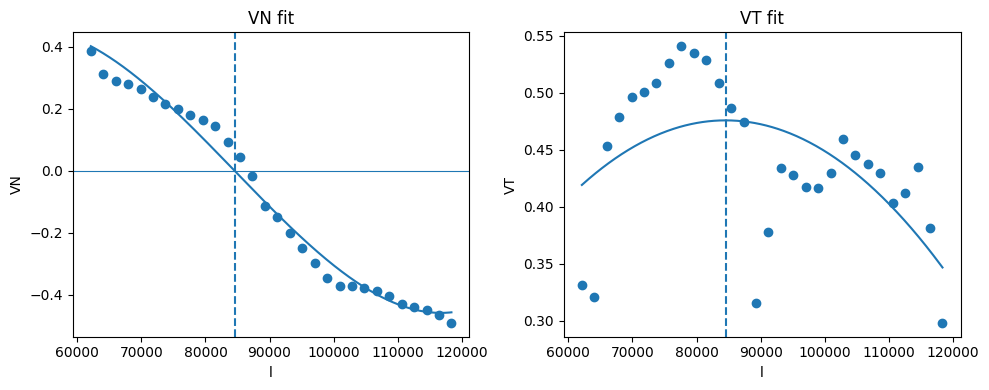

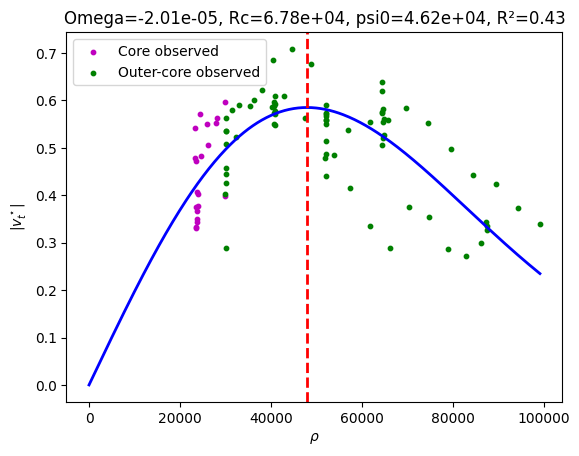

In [9]:
xi, yi, ui, vi = ds_sadcp.x.values, ds_sadcp.y.values, ds_sadcp.u.values, ds_sadcp.v.values

# Project data to transect
df_proj, moca_meta = project_sadcp_to_transect(xi, yi, ui, vi)
# Calculate core ESP parameters
l0, r0, w, Q, Omega = solo(df_proj.l, df_proj.V_T, df_proj.V_N, plot=True)
# Convert transect center coordinates (l0: length along transect, r0: length perpendicular to transect)
# to cartesian coordinates xc, yc
xc, yc = translate_solo_results(df_proj.iloc[0].x, df_proj.iloc[0].y, moca_meta, l0, r0)

# Gather data from beyond the eddy core to estimate outer-core ESP paramters
dx, dy = xi - xc, yi - yc
rho2 = Q[0,0]*dx*dx + 2*Q[1,0]*dx*dy + Q[1,1]*dy*dy
rho_outer = 100_000
outer = rho2 <= rho_outer**2
xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]
vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
Qr_o = np.sqrt((Q[0,0]*dx_o + Q[1,0]*dy_o)**2 + (Q[1,0]*dx_o + Q[1,1]*dy_o)**2)
sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]
Rc, psi0, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=True, km_flag=False)

alpha = 1 # calculate axis ratio (assumes axisymmetric)
w = 2.0*Omega_opt # recalculate vorticity with optimal A
Omega_opt = Omega

data = {'xc': [xc], 'yc': [yc], 'w': [w], 'Q': [Q], 'alpha': [alpha],
        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega], 'time': [ds_sadcp.time.mean().values]}
data = pd.DataFrame(data).iloc[0]
df_res = pd.DataFrame(data).T


### Reconstruct the velocity field using the ESP parameters

In [10]:
x = np.linspace(-150_000, 150_000, 200)
y = np.linspace(-150_000, 150_000, 200)
X, Y = np.meshgrid(x, y, indexing="xy")

dx, dy = X - data.xc, Y - data.yc
q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

fac = 0.5 * data.Omega * np.exp(-rho2 / data.Rc**2)

U = -fac * (2*q12*dx + 2*q22*dy)
V =  fac * (2*q11*dx + 2*q12*dy)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("y","x"), U),
        v=(("y","x"), V),
    ),
    coords=dict(
        x=("x", x),
        y=("y", y),
        x2d=(("y","x"), X),
        y2d=(("y","x"), Y),
    ),
)

ds_model


<xarray.Dataset> Size: 1MB
Dimensions:  (y: 200, x: 200)
Coordinates:
  * x        (x) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
  * y        (y) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
    x2d      (y, x) float64 320kB -1.5e+05 -1.485e+05 ... 1.485e+05 1.5e+05
    y2d      (y, x) float64 320kB -1.5e+05 -1.5e+05 -1.5e+05 ... 1.5e+05 1.5e+05
Data variables:
    u        (y, x) float64 320kB -0.0002819 -0.0003089 ... 0.0001225 0.0001104
    v        (y, x) float64 320kB 0.0002598 0.0002817 ... -0.0001312 -0.0001193

### Find coefiicient of determination $R^2$ between model and data

In [11]:
# Find R2
def model_uv_at_xy(xi, yi, xc, yc, Q, Omega, Rc):
    dx = xi - xc
    dy = yi - yc

    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = Omega * np.exp(-rho2 / (Rc*Rc))

    uhat = -fac * (q12*dx + q22*dy)
    vhat =  fac * (q11*dx + q12*dy)

    return uhat, vhat
    
def vector_R2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

df_xyuv = pd.DataFrame({'time': data.time, 'xi': ds_sadcp.x.values, 'yi': ds_sadcp.y.values,
                        'ui': ds_sadcp.u.values, 'vi': ds_sadcp.v.values})

row = df_res.iloc[0]
df = df_xyuv[df_xyuv.time == row.time]
xi = df.xi.to_numpy(float)
yi = df.yi.to_numpy(float)
u  = df.ui.to_numpy(float)
v  = df.vi.to_numpy(float)
uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
df_res['R2'] = vector_R2(u, v, uhat, vhat)


### Plot results

<xarray.DataArray 'time' ()> Size: 8B
array('2023-10-18T01:35:00.562501248', dtype='datetime64[ns]')
Coordinates:
    z        uint16 2B 37


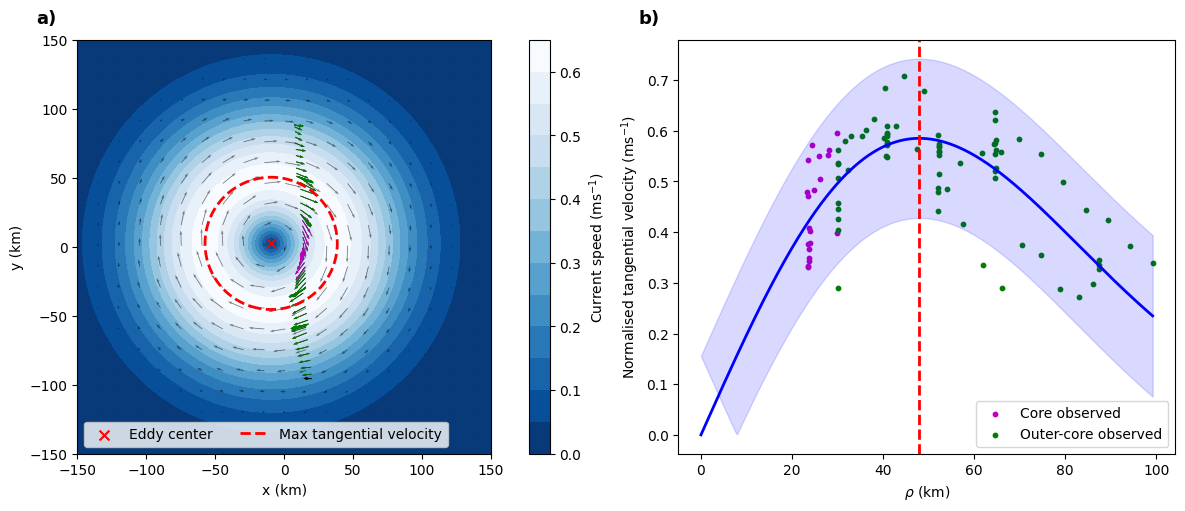

In [12]:
u = ds_model.u
v = ds_model.v
speed = np.hypot(u, v)

# 1D km coords for plotting
x = (ds_model.x / 1e3).values
y = (ds_model.y / 1e3).values

xmin, xmax = -150, 150
ymin, ymax = -150, 150

# 2D ROI mask (ny, nx)
Xkm, Ykm = np.meshgrid(x, y, indexing="xy")
roi = (Xkm >= xmin) & (Xkm <= xmax) & (Ykm >= ymin) & (Ykm <= ymax)

speed_m = speed.where(roi)

vmin = float(speed_m.min(skipna=True))
vmax = float(speed_m.max(skipna=True))
levels = np.arange(0, vmax+.05, .05)

fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

ax = axs[0]

# field first (so vectors on top)
cf = ax.contourf(x, y, speed_m.values, levels=levels, cmap="Blues_r", vmin=vmin, vmax=vmax, zorder=-1)
fig.colorbar(cf, ax=ax, label=r"Current speed (ms$^{-1}$)")

spac, scale = 10, 15
ax.quiver(x[::spac], y[::spac],
              u[::spac,::spac], v[::spac,::spac],
              scale=scale, alpha=.5, width=.002)

# SADCP vectors (x,y already metres -> convert to km; u,v are m/s)
ax.quiver(ds_sadcp.x.values/1e3, ds_sadcp.y.values/1e3,
          ds_sadcp.u.values, ds_sadcp.v.values,
          width=.002, scale=scale)

R = np.hypot(data.xc - ds_sadcp.x.values, data.yc - ds_sadcp.y.values)

core_mask  = R <= 30_000
outer_mask = (R > 30_000) & (R <= 100_000)

ax.quiver(ds_sadcp.x.values[core_mask]/1e3, ds_sadcp.y.values[core_mask]/1e3,
          ds_sadcp.u.values[core_mask], ds_sadcp.v.values[core_mask],
          width=.002, scale=scale, color='m')#, label='Core data')

ax.quiver(ds_sadcp.x.values[outer_mask]/1e3, ds_sadcp.y.values[outer_mask]/1e3,
          ds_sadcp.u.values[outer_mask], ds_sadcp.v.values[outer_mask],
          width=.002, scale=scale, color='g')#, label='Outer-core \ndata') 

# center
ax.scatter(xc/1e3, yc/1e3, marker="x", color="r", s=50, label='Eddy center')

# ellipse contour: compute in metres, but evaluate on the km grid
Xm = Xkm * 1e3
Ym = Ykm * 1e3
dx = Xm - xc
dy = Ym - yc
rho2 = Q[0,0]*dx*dx + 2*Q[0,1]*dx*dy + Q[1,1]*dy*dy

ax.contour(x, y, rho2, levels=[(Rc**2)/2], colors="r", linewidths=2, linestyles='--')
ax.plot([np.nan, np.nan], [np.nan, np.nan], color='r', ls='--', lw=2, label='Max tangential velocity')

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.legend(loc='lower left', ncol=2)
ax.text(-0.10, 1.04, 'a)', transform=ax.transAxes, fontsize=13, fontweight='bold')

ax = axs[1]
out_core_param_fit(rho2_f/1e6, Qr_f/1e3, vt_f, Omega0=Omega,  ax=ax, plot=True, km_flag=True, pred_flag=True)


ax.set_title(''); ax.set_xlabel(r'$\rho$ (km)'); ax.set_ylabel(r'Normalised tangential velocity (ms$^{-1}$)');
ax.text(-0.08, 1.04, 'b)', transform=ax.transAxes, fontsize=13, fontweight='bold')

print(ds_sadcp.time.mean())

plt.show()


In [13]:
df_res


,xc,yc,w,Q,alpha,Rc,psi0,Omega,time,R2
0,-9434.63993,2507.191384,-0.00004,"[[1.0, 0.0], [0.0, 1.0]]",1,67805.07156,46249.456752,-0.000021,2023-10-18 01:35:00.562501248,0.943559
